# Narrow-band filtering of node timeseries
In this tutorial we will show an example of how to narrow-band filter node timeseries. We will additionally demonstrate how the unfiltered node timesereies differs from the narrow-band filtered node timeseries. Lastly we will quickly view phase differences of narrow-band filtered node timeseries.

In [1]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

import mne

import crocopy

from tutorial_utils.data import load_example_data

c:\Users\willy\anaconda3\envs\crosspy_env\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Complex Wavelet Transform background

The electrophysiological recordings contain activity from multiple frequencies and despite broadband data could also be analyzed, it is often decomposed into one or multiple narrowband signals with filtering. There are multiple methods of filtering e.g. IIR/FIR and Complex Wavelet Transform (CWT). Essentially, it is a convolution of broadband signal with complex wavelet - sin-function of given frequency enveloped with Gaussian function. CWT based on Morlet Wavelets has advantage of balancing temporal and spectral resolution: the longer is the wavelet (the more cycles are preserved under the Gaussian envelope) - the better frequency resolution but worse time.

In [2]:
# omega = 5.0
# wavelet_freq = 10.0
# sfreq = 1000.0

def _morlet(sfreq, wavelet_freq, omega, norm=False):
    sigma_t = omega / (2.0 * np.pi * wavelet_freq)
    t = np.arange(0.0, 5.0 * sigma_t, 1.0 / sfreq)
    t = np.r_[-t[::-1], t[1:]]
    oscillation = np.exp(2.0 * 1j * np.pi * wavelet_freq * t)
    gaussian_envelope = np.exp(-(t**2) / (2.0 * sigma_t**2))
    W = oscillation * gaussian_envelope

    if norm:
        W /= np.sqrt(0.5) * np.linalg.norm(W.ravel())

    return W

Wavelets with lower number of cycles are more spread in spectral domain and have lower peak in comparison to wavelets with higher $\omega$

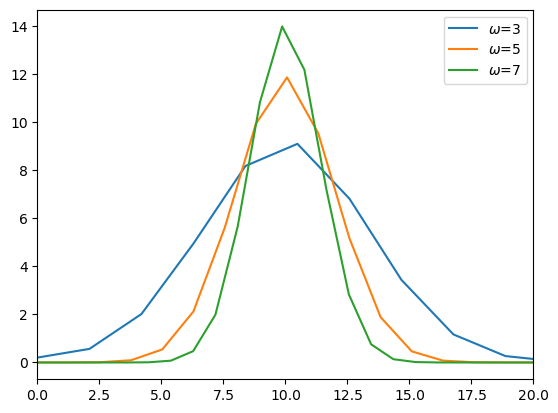

In [3]:
for o in [3,5,7]:
    W = mne.time_frequency.morlet(1000, [10.0], o)[0]
    # t = np.arange(len(W))
    # t -= t.shape[-1]//2
    # plt.plot(t, W.real)
    freqs = np.fft.fftfreq(len(W), d=1/1000)
    fft_morlet = np.fft.fft(W.real)
    fft_morlet_shifted = np.fft.fftshift(fft_morlet)
    freqs_shifted = np.fft.fftshift(freqs)
    plt.plot(freqs_shifted, np.abs(fft_morlet_shifted), label=r'$\omega$' + f'={o}')
    plt.xlim([0,20])
plt.legend()

## Executing narrow-band filtering

In CrosPY to perform CWT one just needs to call a crosspy.preprocessing.signal.filter_data function with parameters:

- sfreq 
Sampling frequency of the data

- frequency
central frequency of the filter

- omega
number of cycles in the wavelet

- n_jobs
either 'cuda' for GPU or integer number for CPU (in this case it falls back to MNE version)

- normalize_wavelet
indicates should a wavelet normalization on sum of its amplitude be performed.

Lets test it with some open data from MNE ( https://mne.tools/mne-connectivity/stable/auto_examples/mne_inverse_envelope_correlation.html#ex-envelope-correlation )

In [4]:
data_broadband, data_labels, data_info = load_example_data()

pxx_freqs, pxx_vals = sp.signal.welch(data_broadband, fs=data_info['sfreq'], nperseg=1000)
channel_to_vis = 101

Text(0, 0.5, 'PSD (a.u.)')

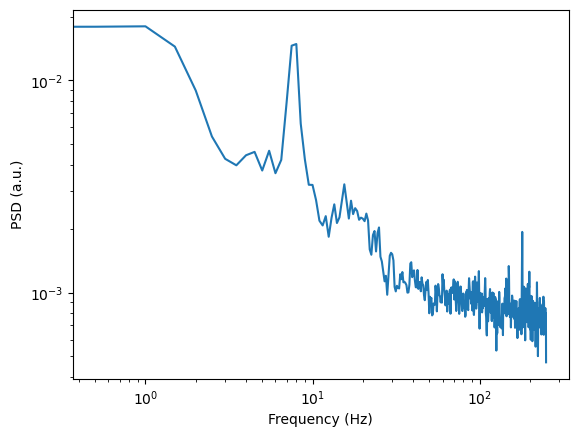

In [5]:
_ = plt.loglog(pxx_freqs, pxx_vals[channel_to_vis])
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (a.u.)')

In [6]:
data_filt = crocopy.preprocessing.signal.filter_data(data_broadband[channel_to_vis:channel_to_vis+1], sfreq=data_info['sfreq'], frequency=7.75, omega=5.0, n_jobs='cuda', normalize_wavelet=True).get()

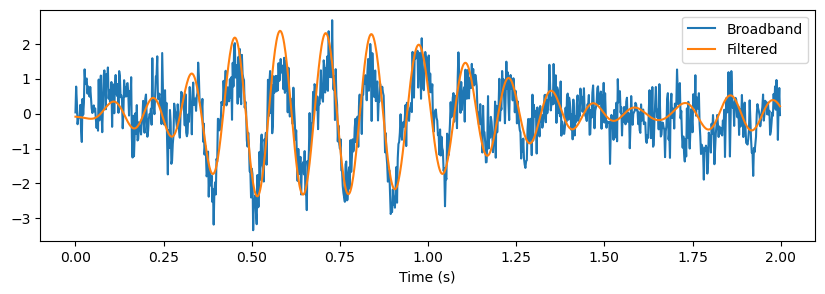

In [7]:
fig, ax = plt.subplots(figsize=(10,3))

vis_ts = np.arange(1000)/data_info['sfreq']

ax.plot(vis_ts, data_broadband[channel_to_vis, 1500:2500], label='Broadband')
ax.plot(vis_ts, data_filt[0, 1500:2500].real*3, label='Filtered')

ax.set_xlabel('Time (s)')

ax.legend()


In [8]:
omega_values = [3, 5, 7]
data_filt_by_omega = dict()

for omega in omega_values:
    data_filt = crocopy.preprocessing.signal.filter_data(data_broadband[channel_to_vis:channel_to_vis+1], sfreq=data_info['sfreq'], frequency=8, 
                                                         omega=omega, n_jobs='cuda', normalize_wavelet=True).get()
    
    data_filt_by_omega[omega] = data_filt

Text(0.5, 0, 'Time (s)')

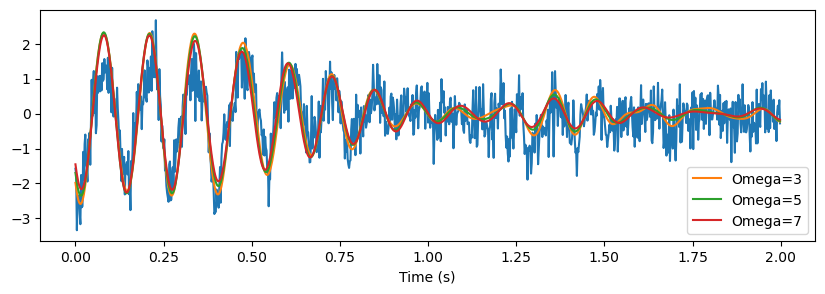

In [9]:
fig, ax = plt.subplots(figsize=(10,3))

ax.plot(vis_ts, data_broadband[channel_to_vis, 1750:2750])

for omega, data_filt in data_filt_by_omega.items():
    ax.plot(vis_ts, data_filt[0, 1750:2750].real*3, label=f'Omega={omega}')

ax.legend()

ax.set_xlabel('Time (s)')